# TP2 Detector de máximo enfoque
Autor : Juan Fajardo 

Incluye:
- Métrica en dominio frecuencial usando el artículo: *Image Sharpness Measure for Blurred Images in Frequency Domain*.
- Curva sobre todo el frame.
- Curvas sobre ROI central del 5% y del 10% del área total.
- Detección automática del frame de máximo enfoque.


In [7]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.signal import find_peaks
except Exception:
    find_peaks = None


plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True

## Cargar video

In [11]:
from pathlib import Path

video_ruta = "focus_video.mov"

if not Path(video_ruta).exists():
    raise FileNotFoundError(f"No se encontró el video: {video_ruta}")

print("Video cargado:", video_ruta)

Video cargado: focus_video.mov


## Funciones del detector

La ROI es cuadrada y se centra en el frame. Su lado se calcula para que el área sea aproximadamente 5% o 10% del área total.


El procesamiento comienza convirtiendo cada frame del video a escala de grises en formato float32, ya que la métrica de enfoque se aplica sobre intensidades y no sobre información de color. Luego, opcionalmente, se define una región de interés (ROI) centrada, cuya área corresponde aproximadamente a un porcentaje del área total del frame, permitiendo analizar el enfoque en zonas específicas de la imagen.

La métrica de enfoque utilizada corresponde a la definida en el paper “Image Sharpness Measure for Blurred Images in Frequency Domain”, la cual se basa en el análisis espectral de la imagen. Para cada frame (o ROI), se calcula la Transformada de Fourier 2D, se centra el espectro y se obtiene su magnitud. A partir de este espectro, se determina un umbral como una fracción del valor máximo, y se cuenta la cantidad de componentes que superan dicho umbral. Este valor, normalizado por el tamaño de la imagen, define el nivel de enfoque: imágenes más nítidas presentan mayor contenido de altas frecuencias y, por lo tanto, un valor de métrica más elevado.

Finalmente, para robustecer la detección del punto de máximo enfoque a lo largo del video, la curva de valores obtenidos frame a frame se suaviza mediante un promedio móvil, y se identifican los picos utilizando un algoritmo de detección de máximos. De esta manera, se determina automáticamente el frame correspondiente al máximo enfoque. Adicionalmente, se incluye un proceso de realce opcional basado en unsharp masking, que permite mejorar la percepción visual del enfoque en las imágenes analizadas

In [ ]:
def frame_a_gris(frame_bgr):
    """Convierte un frame BGR a escala de grises en float32."""
    if frame_bgr.ndim == 2:
        gris = frame_bgr
    else:
        gris = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    return gris.astype(np.float32)


def roi_centrada(frame, fraccion_area):
    """ROI cuadrada centrada con área aproximada fraccion_area del total."""
    alto, ancho = frame.shape[:2]
    lado = int(round(np.sqrt(fraccion_area * alto * ancho)))
    lado = max(1, min(lado, alto, ancho))

    y0 = (alto - lado) // 2
    x0 = (ancho - lado) // 2
    return frame[y0:y0 + lado, x0:x0 + lado]


def metrica_frecuencial_enfoque(gris):
    """Métrica definida en el paper de sharpness en dominio de frecuencia."""
    if gris.size == 0:
        return 0.0

    transformada = np.fft.fft2(gris)
    transformada_centrada = np.fft.fftshift(transformada)
    espectro = np.abs(transformada_centrada)

    maximo = float(np.max(espectro))
    if maximo <= 0:
        return 0.0

    umbral = maximo / 1000.0
    cantidad = float(np.count_nonzero(espectro > umbral))
    return cantidad / float(gris.shape[0] * gris.shape[1])


def suavizado_movil(valores, ventana=5):
    if ventana <= 1 or len(valores) < ventana:
        return np.array(valores, dtype=np.float32)
    valores = np.array(valores, dtype=np.float32)
    kernel = np.ones(ventana, dtype=np.float32) / float(ventana)
    relleno = np.pad(valores, (ventana // 2, ventana - 1 - ventana // 2), mode='edge')
    return np.convolve(relleno, kernel, mode='valid')


def detectar_maximo_enfoque(puntajes, ventana_suavizado=5):
    """Devuelve el índice del frame de máximo enfoque y la curva suavizada."""
    puntajes_suaves = suavizado_movil(puntajes, ventana=ventana_suavizado)

    if find_peaks is not None and len(puntajes_suaves) >= 3:
        prominencia = max(1e-8, 0.05 * float(np.max(puntajes_suaves) - np.min(puntajes_suaves)))
        picos, _ = find_peaks(puntajes_suaves, prominence=prominencia, distance=max(1, ventana_suavizado))
        if len(picos) > 0:
            mejor = int(picos[np.argmax(puntajes_suaves[picos])])
            return {
                'puntajes': puntajes_suaves,
                'indice_max': mejor,
                'valor_max': float(puntajes_suaves[mejor]),
                'picos': picos,
            }

    mejor = int(np.argmax(puntajes_suaves)) if len(puntajes_suaves) else 0
    return {
        'puntajes': puntajes_suaves,
        'indice_max': mejor,
        'valor_max': float(puntajes_suaves[mejor]) if len(puntajes_suaves) else 0.0,
        'picos': np.array([mejor], dtype=int),
    }


def mascara_unsharp(imagen, sigma=1.2, alfa=1.2):
    """Realce por unsharp masking."""
    imagen_f = imagen.astype(np.float32)
    borrosa = cv2.GaussianBlur(imagen_f, (0, 0), sigmaX=sigma, sigmaY=sigma)
    realzada = cv2.addWeighted(imagen_f, 1.0 + alfa, borrosa, -alfa, 0.0)
    return np.clip(realzada, 0, 255).astype(np.uint8)

## Procesar video

Se calculan tres curvas:
- Frame completo.
- ROI central del 5%.
- ROI central del 10%.

In [13]:
fracciones_roi = (0.05, 0.10)
frames = []
puntajes_frame_completo = []
puntajes_roi = {f'roi_{int(f * 100)}': [] for f in fracciones_roi}

captura = cv2.VideoCapture(video_ruta)
if not captura.isOpened():
    raise FileNotFoundError(f'No se pudo abrir el video: {video_ruta}')

while True:
    exito, frame = captura.read()
    if not exito:
        break

    frames.append(frame)
    gris = frame_a_gris(frame)

    # Todo el frame
    puntajes_frame_completo.append(metrica_frecuencial_enfoque(gris))

    # ROIs centrales
    for fraccion in fracciones_roi:
        etiqueta = f'roi_{int(fraccion * 100)}'
        subregion = roi_centrada(gris, fraccion)
        puntajes_roi[etiqueta].append(metrica_frecuencial_enfoque(subregion))

captura.release()

if not frames:
    raise RuntimeError('El video no contiene frames válidos.')

print('Cantidad de frames:', len(frames))
print('Primeras 5 muestras frame completo:', puntajes_frame_completo[:5])

Cantidad de frames: 171
Primeras 5 muestras frame completo: [0.006957465277777778, 0.006922743055555555, 0.006922743055555555, 0.006879340277777778, 0.0068706597222222224]


El video contiene 171 frames válidos. Al procesar el frame completo con la métrica de enfoque en dominio de frecuencia, las primeras cinco muestras obtenidas fueron 0.00696, 0.00692, 0.00692, 0.00688 y 0.00687. Estos valores muestran una variación pequeña entre frames consecutivos, lo que indica que en ese tramo inicial el nivel de enfoque se mantiene relativamente estable.

Si quieres una versión más corta para poner debajo de la salida:

Se procesaron 171 frames. Las primeras muestras de la métrica para el frame completo fueron cercanas entre sí, lo que sugiere un comportamiento estable del enfoque al inicio del video.

In [14]:
resultados = {}
resultados['frame_completo'] = detectar_maximo_enfoque(np.array(puntajes_frame_completo, dtype=np.float32))
resultados['roi_5'] = detectar_maximo_enfoque(np.array(puntajes_roi['roi_5'], dtype=np.float32))
resultados['roi_10'] = detectar_maximo_enfoque(np.array(puntajes_roi['roi_10'], dtype=np.float32))

for nombre, res in resultados.items():
    print(f"{nombre:>13} | frame = {res['indice_max']:4d} | score = {res['valor_max']:.6f} | picos = {len(res['picos'])}")

frame_completo | frame =  109 | score = 0.027607 | picos = 1
        roi_5 | frame =  111 | score = 0.446310 | picos = 1
       roi_10 | frame =  111 | score = 0.330280 | picos = 1


El máximo enfoque se detectó en el frame 109 (frame completo) y en el frame 111 para ambas ROI. La detección fue consistente, con un único pico en cada caso, lo que indica un comportamiento estable del algoritmo. Las ROI presentan valores de métrica más altos al concentrar el análisis en zonas con mayor contenido de altas frecuencias.

## Gráfico de curvas

La figura marca el punto de máximo enfoque detectado para cada experimento.

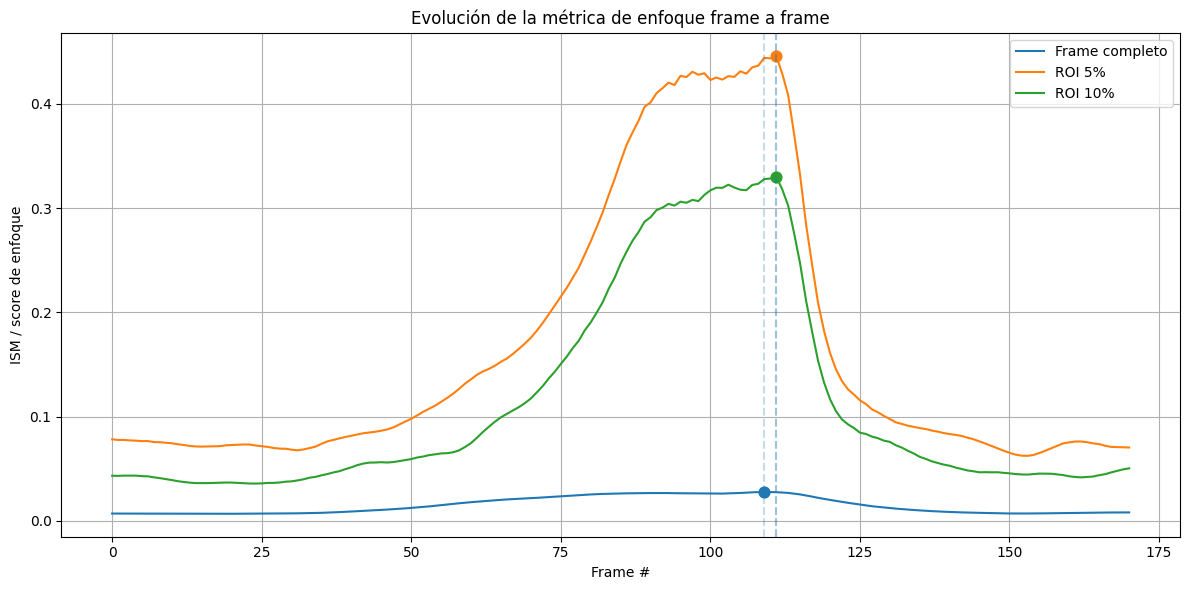

In [15]:
plt.figure(figsize=(12, 6))

curvas = {
    'Frame completo': resultados['frame_completo']['puntajes'],
    'ROI 5%': resultados['roi_5']['puntajes'],
    'ROI 10%': resultados['roi_10']['puntajes'],
}

for nombre, curva in curvas.items():
    plt.plot(curva, label=nombre)

for clave in ['frame_completo', 'roi_5', 'roi_10']:
    idx = resultados[clave]['indice_max']
    val = resultados[clave]['valor_max']
    plt.scatter([idx], [val], s=60)
    plt.axvline(idx, linestyle='--', alpha=0.25)

plt.title('Evolución de la métrica de enfoque frame a frame')
plt.xlabel('Frame #')
plt.ylabel('ISM / score de enfoque')
plt.legend()
plt.tight_layout()
plt.show()

## Mostrar el frame de máximo enfoque

Se guarda el frame original y una versión con unsharp masking.

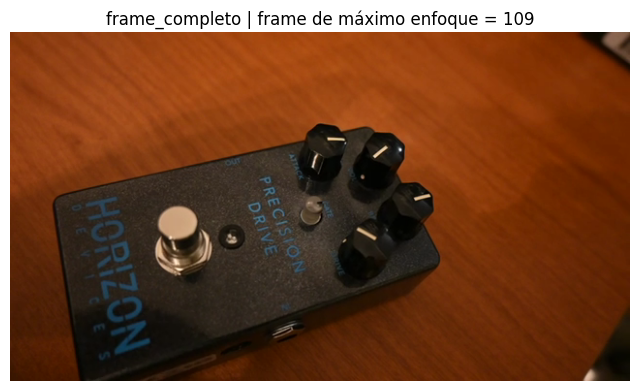

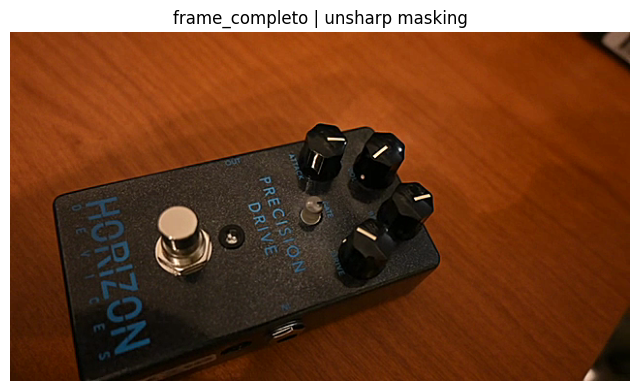

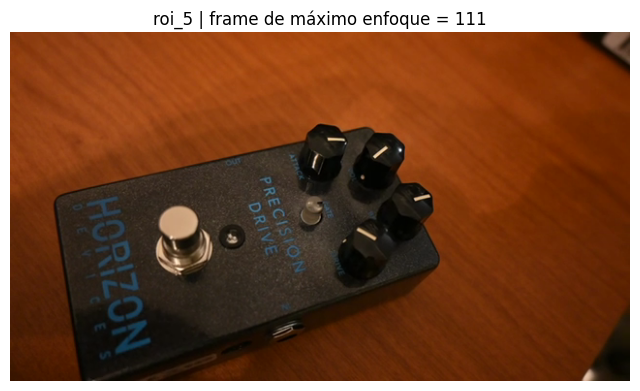

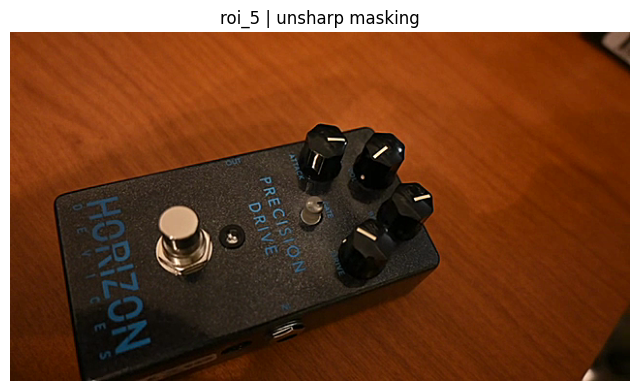

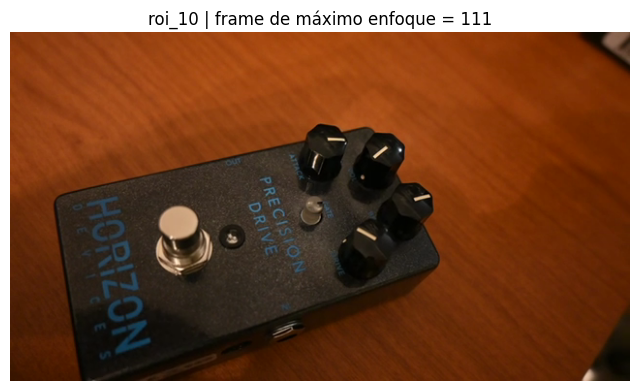

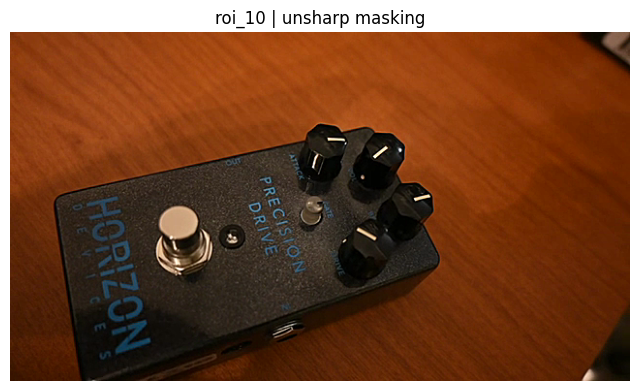

In [16]:
def mostrar_frame_con_titulo(frame_bgr, titulo):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

for nombre, res in resultados.items():
    idx = res['indice_max']
    frame_mejor = frames[idx]
    realzado = mascara_unsharp(frame_mejor, sigma=1.2, alfa=1.2)

    mostrar_frame_con_titulo(frame_mejor, f'{nombre} | frame de máximo enfoque = {idx}')
    mostrar_frame_con_titulo(realzado, f'{nombre} | unsharp masking')

## Análisis de resultados

La evolución de la métrica de enfoque a lo largo de los frames muestra un comportamiento consistente en las tres configuraciones analizadas (frame completo, ROI 5% y ROI 10%). En todos los casos se observa un incremento progresivo del valor de la métrica hasta alcanzar un máximo alrededor de los frames 109–111, seguido de una caída abrupta.

Este comportamiento es característico de un proceso de enfoque/desenfoque, donde el contenido de altas frecuencias aumenta a medida que la imagen se vuelve más nítida, alcanzando un pico en el punto de máximo enfoque, y disminuyendo posteriormente cuando la imagen vuelve a desenfocarse.

### Comparación entre configuraciones
Frame completo (azul):
-Presenta valores de métrica más bajos.
-Curva más suave y menos pronunciada.
-Esto se debe a que incluye regiones fuera de foco (fondo), lo que diluye el contenido de altas frecuencias.

ROI 10% (verde):
-Valores más altos que el frame completo.
-Curva más definida.
-Mejora la sensibilidad al enfocarse en la zona central.

ROI 5% (naranja):
-Presenta los valores más altos.
-Curva más pronunciada y clara.
-Detecta el máximo enfoque de forma más precisa.

Además, en los tres casos se detecta un único pico, lo que indica una escena con un único punto claro de mejor enfoque.

En conclusión se puedo representar que el método basado en dominio de frecuencia permite detectar de manera robusta el punto de máximo enfoque en un video. El uso de regiones de interés centradas mejora significativamente la sensibilidad del detector, al reducir la influencia de zonas irrelevantes o desenfocadas.